# 03 — Tactical Decision Intelligence

## From Aggregate Progression to Context-Aware Decisions

Notebook 02 established the aggregate reward–risk baseline for progressive passing.
This notebook focuses on the contextual question that remains:

> **Under which defensive conditions is progressive passing easier or harder to execute, and how can those conditions be translated into a decision-oriented reward–risk view?**

The analysis is deliberately compact. It contains three analytical stages:

1. **Defensive and Tactical Context** — construct interpretable StatsBomb 360 context features for progressive pass attempts;
2. **Same Destination, Different Context** — compare execution reliability under different contexts while holding destination state approximately constant;
3. **Decision Intelligence** — combine completion reliability, attacking reward, and a failed-pass exposure proxy into a transparent decision framework.

The final section will summarize findings and limitations after the empirical outputs have been reviewed.


In [6]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)


## Setup and Data Handoff

The notebook uses the processed outputs from Notebook 02 and reconstructs the corresponding progressive pass events from the raw StatsBomb event and 360 files.

The reconstruction is intentional: Notebook 01 did not retain the StatsBomb event UUID, while the 360 files are keyed by `event_uuid`. Rebuilding the progressive pass table from the raw event files allows the 360 freeze frames to be joined without relying on approximate time- or coordinate-based matching.

The progression definition is kept identical to Notebook 01:

- the pass enters a more advanced pitch third, **or**
- the pass advances at least 25 StatsBomb coordinate units.

The xT surface estimated in Notebook 02 is then mapped back to the reconstructed passes.


In [7]:
# ---------------------------------------------------------
# Locate repository, config, processed outputs and raw data
# ---------------------------------------------------------

# Optional manual fallback:
# If automatic detection fails, set this to your repository root, e.g.
# REPO_DIR_OVERRIDE = Path(r"C:\Users\...\football-performance-analytics")
REPO_DIR_OVERRIDE = None

CURRENT_DIR = Path.cwd().resolve()

if REPO_DIR_OVERRIDE is not None:
    REPO_DIR = Path(REPO_DIR_OVERRIDE).expanduser().resolve()
else:
    search_candidates = [CURRENT_DIR, *CURRENT_DIR.parents]

    REPO_DIR = next(
        (
            path
            for path in search_candidates
            if (path / "processed").is_dir()
            and (path / "config.json").is_file()
        ),
        None,
    )

if REPO_DIR is None:
    print("Current working directory:")
    print(CURRENT_DIR)

    print("\nSearched directories:")
    for path in [CURRENT_DIR, *CURRENT_DIR.parents]:
        print(" -", path)

    raise FileNotFoundError(
        "\nRepository root could not be detected automatically.\n"
        "Expected both processed/ and config.json in the repository root.\n\n"
        "Either:\n"
        "1. open this notebook from the repository's notebooks/ directory, or\n"
        "2. set REPO_DIR_OVERRIDE manually at the top of this cell."
    )

PROCESSED_DIR = REPO_DIR / "processed"
CONFIG_PATH = REPO_DIR / "config.json"

if not CONFIG_PATH.exists():
    raise FileNotFoundError(f"config.json not found: {CONFIG_PATH}")

with open(CONFIG_PATH, "r", encoding="utf-8") as f:
    config = json.load(f)

DATA_DIR = Path(config["statsbomb_data_dir"]).expanduser()
THREE_SIXTY_DIR = DATA_DIR / "three-sixty"
EVENTS_DIR = DATA_DIR / "events"

if not DATA_DIR.exists():
    raise FileNotFoundError(f"StatsBomb data directory not found: {DATA_DIR}")

if not EVENTS_DIR.exists():
    raise FileNotFoundError(f"StatsBomb events directory not found: {EVENTS_DIR}")

if not THREE_SIXTY_DIR.exists():
    raise FileNotFoundError(f"StatsBomb 360 directory not found: {THREE_SIXTY_DIR}")

attempts_path = PROCESSED_DIR / "pass_attempts_for_tactical_analysis.csv"
xt_path = PROCESSED_DIR / "xt_state_values.csv"

if not attempts_path.exists() or not xt_path.exists():
    raise FileNotFoundError(
        "Notebook 02 outputs were not found. Run Notebook 02 first.\n"
        f"Expected:\n- {attempts_path}\n- {xt_path}"
    )

pass_attempts_baseline_df = pd.read_csv(attempts_path)
xt_state_values_df = pd.read_csv(xt_path)

required_attempt_cols = {"match_id", "is_progressive_attempt", "pass_success"}
missing_attempt_cols = required_attempt_cols.difference(
    pass_attempts_baseline_df.columns
)
if missing_attempt_cols:
    raise KeyError(
        "Missing columns in pass_attempts_for_tactical_analysis.csv: "
        f"{sorted(missing_attempt_cols)}"
    )

required_xt_cols = {"state_id", "xT"}
missing_xt_cols = required_xt_cols.difference(xt_state_values_df.columns)
if missing_xt_cols:
    raise KeyError(
        f"Missing columns in xt_state_values.csv: {sorted(missing_xt_cols)}"
    )

print("Repository root:", REPO_DIR)
print("Processed data directory:", PROCESSED_DIR)
print("StatsBomb data directory:", DATA_DIR)
print("Matches in Notebook 02 baseline:", pass_attempts_baseline_df["match_id"].nunique())
print(
    "Progressive attempts in Notebook 02 baseline:",
    int(pass_attempts_baseline_df["is_progressive_attempt"].sum()),
)


Repository root: C:\Users\ayael\Documents\soccer analysis\football-performance-analytics
Processed data directory: C:\Users\ayael\Documents\soccer analysis\football-performance-analytics\processed
StatsBomb data directory: C:\Users\ayael\Documents\soccer analysis\Soccer Analytic Projekt\open-data\data
Matches in Notebook 02 baseline: 34
Progressive attempts in Notebook 02 baseline: 3342


# 3. Defensive and Tactical Context

## 3.1 360 Data Availability

StatsBomb 360 freeze frames provide the locations of visible players at the moment of an event. They do **not** represent the complete position of every player on the pitch; only players inside the recorded visible area are available.

For each progressive pass attempt, the notebook therefore distinguishes between:

- the event-level pass information, which is available for the full analytical sample;
- the 360 contextual information, which is available only when a matching freeze frame exists.

All context features below should consequently be interpreted as **visible-frame context measures**.


In [8]:
# ---------------------------------------------------------
# Reconstruct dynamic-possession pass events and attach 360
# ---------------------------------------------------------

DYNAMIC_PLAY_PATTERNS = {
    "Regular Play",
    "From Counter",
    "From Keeper",
    "Other",
}

match_ids = sorted(
    pass_attempts_baseline_df["match_id"].dropna().astype(int).unique()
)

rows = []
missing_event_files = []
missing_360_files = []

for match_id in match_ids:
    events_path = EVENTS_DIR / f"{match_id}.json"
    three_sixty_path = THREE_SIXTY_DIR / f"{match_id}.json"

    if not events_path.exists():
        missing_event_files.append(match_id)
        continue

    with open(events_path, "r", encoding="utf-8") as f:
        events = json.load(f)

    if three_sixty_path.exists():
        with open(three_sixty_path, "r", encoding="utf-8") as f:
            frames_360 = json.load(f)

        frame_lookup = {
            frame.get("event_uuid"): frame
            for frame in frames_360
            if frame.get("event_uuid") is not None
        }
    else:
        frame_lookup = {}
        missing_360_files.append(match_id)

    for event in events:
        event_type = event.get("type", {}).get("name")
        if event_type != "Pass":
            continue

        play_pattern_name = event.get("play_pattern", {}).get("name")
        if play_pattern_name not in DYNAMIC_PLAY_PATTERNS:
            continue

        start = event.get("location")
        pass_obj = event.get("pass", {})
        end = pass_obj.get("end_location")

        if not (
            isinstance(start, list)
            and len(start) >= 2
            and isinstance(end, list)
            and len(end) >= 2
        ):
            continue

        event_id = event.get("id")
        outcome = pass_obj.get("outcome", {}).get("name")
        frame = frame_lookup.get(event_id)

        rows.append(
            {
                "event_id": event_id,
                "match_id": match_id,
                "minute": event.get("minute"),
                "second": event.get("second"),
                "team_name": event.get("team", {}).get("name"),
                "player_name": event.get("player", {}).get("name"),
                "recipient_name": pass_obj.get("recipient", {}).get("name"),
                "play_pattern_name": play_pattern_name,
                "pass_type": pass_obj.get("type", {}).get("name"),
                "pass_outcome": outcome,
                "pass_success": outcome is None,
                "start_x": float(start[0]),
                "start_y": float(start[1]),
                "end_x": float(end[0]),
                "end_y": float(end[1]),
                "freeze_frame": frame.get("freeze_frame", []) if frame else [],
                "visible_area": frame.get("visible_area") if frame else None,
                "has_360": frame is not None,
            }
        )

raw_passes_360_df = pd.DataFrame(rows)

if raw_passes_360_df.empty:
    raise RuntimeError("No dynamic-possession pass events were reconstructed.")

# Geometry identical to Notebook 01
raw_passes_360_df["pass_length"] = np.sqrt(
    (raw_passes_360_df["end_x"] - raw_passes_360_df["start_x"]) ** 2
    + (raw_passes_360_df["end_y"] - raw_passes_360_df["start_y"]) ** 2
)

raw_passes_360_df["forward_distance"] = (
    raw_passes_360_df["end_x"] - raw_passes_360_df["start_x"]
)


def third_order_from_x(x):
    if x < 40:
        return 1
    if x < 80:
        return 2
    return 3


raw_passes_360_df["start_third_order"] = raw_passes_360_df["start_x"].map(third_order_from_x)
raw_passes_360_df["end_third_order"] = raw_passes_360_df["end_x"].map(third_order_from_x)

raw_passes_360_df["advanced_third"] = (
    raw_passes_360_df["end_third_order"]
    > raw_passes_360_df["start_third_order"]
)

raw_passes_360_df["is_progressive_attempt"] = (
    raw_passes_360_df["advanced_third"]
    | (raw_passes_360_df["forward_distance"] >= 25)
)

progressive_all_df = raw_passes_360_df[
    raw_passes_360_df["is_progressive_attempt"]
].copy()

baseline_progressive_n = int(
    pass_attempts_baseline_df["is_progressive_attempt"].sum()
)
reconstructed_progressive_n = len(progressive_all_df)

print("Dynamic-possession passes reconstructed:", len(raw_passes_360_df))
print("Progressive attempts reconstructed:", reconstructed_progressive_n)
print("Progressive attempts in Notebook 02 baseline:", baseline_progressive_n)
print("Difference:", reconstructed_progressive_n - baseline_progressive_n)
print("Missing event files:", len(missing_event_files))
print("Missing 360 files:", len(missing_360_files))


Dynamic-possession passes reconstructed: 19397
Progressive attempts reconstructed: 3342
Progressive attempts in Notebook 02 baseline: 3342
Difference: 0
Missing event files: 0
Missing 360 files: 0


In [9]:
# ---------------------------------------------------------
# Map the Notebook 02 xT surface to reconstructed pass events
# ---------------------------------------------------------

XT_COLS = 12
XT_ROWS = 8
PITCH_LENGTH = 120
PITCH_WIDTH = 80
CELL_WIDTH = PITCH_LENGTH / XT_COLS
CELL_HEIGHT = PITCH_WIDTH / XT_ROWS

xt_lookup = (
    xt_state_values_df
    .set_index("state_id")["xT"]
    .to_dict()
)


def state_id_from_xy(x, y):
    col = int(np.floor(x / CELL_WIDTH))
    row = int(np.floor(y / CELL_HEIGHT))
    col = int(np.clip(col, 0, XT_COLS - 1))
    row = int(np.clip(row, 0, XT_ROWS - 1))
    return row * XT_COLS + col


progressive_all_df["start_state_id"] = [
    state_id_from_xy(x, y)
    for x, y in zip(progressive_all_df["start_x"], progressive_all_df["start_y"])
]

progressive_all_df["end_state_id"] = [
    state_id_from_xy(x, y)
    for x, y in zip(progressive_all_df["end_x"], progressive_all_df["end_y"])
]

progressive_all_df["xT_start"] = progressive_all_df["start_state_id"].map(xt_lookup)
progressive_all_df["xT_end"] = progressive_all_df["end_state_id"].map(xt_lookup)

# Reward is only assigned to successfully completed passes.
progressive_all_df["delta_xT"] = np.where(
    progressive_all_df["pass_success"],
    progressive_all_df["xT_end"] - progressive_all_df["xT_start"],
    np.nan,
)

coverage_summary = pd.DataFrame(
    {
        "metric": [
            "Progressive attempts",
            "Progressive attempts with 360",
            "Completed progressive attempts",
            "Completed progressive attempts with 360",
        ],
        "count": [
            len(progressive_all_df),
            int(progressive_all_df["has_360"].sum()),
            int(progressive_all_df["pass_success"].sum()),
            int((progressive_all_df["pass_success"] & progressive_all_df["has_360"]).sum()),
        ],
    }
)

coverage_summary["share_of_all_progressive_pct"] = (
    coverage_summary["count"] / len(progressive_all_df) * 100
)

display(coverage_summary.round(2))

coverage_by_match = (
    progressive_all_df
    .groupby("match_id")
    .agg(
        progressive_attempts=("event_id", "size"),
        attempts_with_360=("has_360", "sum"),
    )
    .reset_index()
)
coverage_by_match["coverage_pct"] = (
    coverage_by_match["attempts_with_360"]
    / coverage_by_match["progressive_attempts"]
    * 100
)

print("\n360 coverage by match:")
display(coverage_by_match.describe().round(2))


,metric,count,share_of_all_progressive_pct
0,Progressive attempts,3342,100.00
1,Progressive attempts with 360,2614,78.22
2,Completed progressive attempts,2412,72.17
3,Completed progressive attempts with 360,1905,57.00



360 coverage by match:


,match_id,progressive_attempts,attempts_with_360,coverage_pct
count,34.00,34.00,34.00,34.00
mean,3895199.09,98.29,76.88,77.48
std,89.86,14.26,27.24,24.99
min,3895052.00,67.00,0.00,0.00
25%,3895124.25,91.75,73.25,81.78
50%,3895198.00,100.50,83.50,85.65
75%,3895272.75,106.00,92.00,87.46
max,3895348.00,127.00,115.00,95.83


In [10]:
# ---------------------------------------------------------
# 360 coverage bias check
# ---------------------------------------------------------

coverage_bias_check = (
    progressive_all_df
    .groupby("has_360")
    .agg(
        attempts=("event_id", "size"),
        completion_rate=("pass_success", "mean"),
        mean_delta_xT_if_completed=("delta_xT", "mean"),
        median_delta_xT_if_completed=("delta_xT", "median"),
    )
    .reset_index()
)

coverage_bias_check["completion_rate_pct"] = (
    coverage_bias_check["completion_rate"] * 100
)

display(
    coverage_bias_check[
        [
            "has_360",
            "attempts",
            "completion_rate_pct",
            "mean_delta_xT_if_completed",
            "median_delta_xT_if_completed",
        ]
    ].round(4)
)


,has_360,attempts,completion_rate_pct,mean_delta_xT_if_completed,median_delta_xT_if_completed
0,False,728,69.6429,0.0064,0.0052
1,True,2614,72.8768,0.0067,0.0048


## 3.2–3.6 Context Features

The 360 features are designed as transparent geometric proxies rather than hidden model features.

### Receiver space

The open-data freeze frame does not identify the pass recipient directly. The intended receiver position is therefore approximated by the visible non-actor teammate closest to the recorded pass endpoint. Receiver space is then measured as the distance from this receiver proxy to the nearest visible opponent.

A larger value means more space around the estimated receiver.

### Passer pressure

Passer pressure is represented by the distance from the pass origin to the nearest visible opponent. A smaller value indicates stronger immediate pressure around the passer.

### Packing

`packing_count` counts visible opponents whose x-position lies between the pass start and end x-coordinates at the moment of the pass. It is therefore a geometric **opponents-bypassed proxy**, not a full tactical packing model.

### Passing-lane density

Lane density counts visible opponents located within a corridor around the line segment connecting the pass origin and endpoint. The primary corridor half-width is 4 coordinate units; 3- and 5-unit variants are retained for a simple sensitivity check.

### Line-breaking / penetration proxies

A pass is flagged as line-breaking when it is progressive and bypasses at least two visible opponents. Penetration is represented separately through entries into the final third or penalty box.

These definitions are intentionally explicit so that the later decision analysis remains interpretable.


In [11]:
# ---------------------------------------------------------
# Geometric helpers for 360 context features
# ---------------------------------------------------------


def euclidean_distance(x1, y1, x2, y2):
    return float(np.hypot(x2 - x1, y2 - y1))


def point_to_segment_distance(px, py, x1, y1, x2, y2):
    vx = x2 - x1
    vy = y2 - y1
    wx = px - x1
    wy = py - y1

    segment_sq = vx * vx + vy * vy
    if segment_sq == 0:
        return euclidean_distance(px, py, x1, y1)

    t = (wx * vx + wy * vy) / segment_sq
    t = np.clip(t, 0.0, 1.0)

    proj_x = x1 + t * vx
    proj_y = y1 + t * vy

    return euclidean_distance(px, py, proj_x, proj_y)


def is_inside_opponent_box(x, y):
    # StatsBomb 120 x 80 pitch; opponent penalty area approximately x >= 102,
    # y between 18 and 62.
    return (x >= 102) and (18 <= y <= 62)


def extract_360_context(row):
    frame = row["freeze_frame"]

    empty = {
        "n_visible_opponents": np.nan,
        "n_visible_teammates": np.nan,
        "passer_pressure_dist": np.nan,
        "receiver_proxy_x": np.nan,
        "receiver_proxy_y": np.nan,
        "receiver_proxy_error": np.nan,
        "receiver_space_dist": np.nan,
        "packing_count": np.nan,
        "lane_density_3": np.nan,
        "lane_density_4": np.nan,
        "lane_density_5": np.nan,
    }

    if not isinstance(frame, list) or len(frame) == 0:
        return empty

    valid_players = []
    for player in frame:
        loc = player.get("location")
        if not isinstance(loc, list) or len(loc) < 2:
            continue

        valid_players.append(
            {
                "x": float(loc[0]),
                "y": float(loc[1]),
                "teammate": bool(player.get("teammate")),
                "actor": bool(player.get("actor")),
                "keeper": bool(player.get("keeper")),
            }
        )

    opponents = [p for p in valid_players if not p["teammate"]]
    teammates = [
        p for p in valid_players
        if p["teammate"] and not p["actor"]
    ]

    x1, y1 = row["start_x"], row["start_y"]
    x2, y2 = row["end_x"], row["end_y"]

    # Passer pressure: nearest visible opponent to pass origin
    if opponents:
        passer_pressure_dist = min(
            euclidean_distance(x1, y1, p["x"], p["y"])
            for p in opponents
        )
    else:
        passer_pressure_dist = np.nan

    # Receiver proxy: visible teammate nearest to pass endpoint
    if teammates:
        receiver_proxy = min(
            teammates,
            key=lambda p: euclidean_distance(x2, y2, p["x"], p["y"]),
        )

        receiver_proxy_x = receiver_proxy["x"]
        receiver_proxy_y = receiver_proxy["y"]
        receiver_proxy_error = euclidean_distance(
            x2, y2, receiver_proxy_x, receiver_proxy_y
        )

        if opponents:
            receiver_space_dist = min(
                euclidean_distance(
                    receiver_proxy_x,
                    receiver_proxy_y,
                    p["x"],
                    p["y"],
                )
                for p in opponents
            )
        else:
            receiver_space_dist = np.nan
    else:
        receiver_proxy_x = np.nan
        receiver_proxy_y = np.nan
        receiver_proxy_error = np.nan
        receiver_space_dist = np.nan

    # Packing proxy: visible opponents bypassed in the attacking x-direction
    if x2 > x1:
        packing_count = sum(
            (p["x"] > x1) and (p["x"] <= x2)
            for p in opponents
        )
    else:
        packing_count = 0

    # Passing-lane density: visible opponents within a corridor around the pass segment
    lane_distances = [
        point_to_segment_distance(p["x"], p["y"], x1, y1, x2, y2)
        for p in opponents
    ]

    lane_density_3 = sum(d <= 3 for d in lane_distances)
    lane_density_4 = sum(d <= 4 for d in lane_distances)
    lane_density_5 = sum(d <= 5 for d in lane_distances)

    return {
        "n_visible_opponents": len(opponents),
        "n_visible_teammates": len(teammates),
        "passer_pressure_dist": passer_pressure_dist,
        "receiver_proxy_x": receiver_proxy_x,
        "receiver_proxy_y": receiver_proxy_y,
        "receiver_proxy_error": receiver_proxy_error,
        "receiver_space_dist": receiver_space_dist,
        "packing_count": packing_count,
        "lane_density_3": lane_density_3,
        "lane_density_4": lane_density_4,
        "lane_density_5": lane_density_5,
    }


In [12]:
# ---------------------------------------------------------
# Build context features for progressive attempts with 360
# ---------------------------------------------------------

progressive_360_df = progressive_all_df[
    progressive_all_df["has_360"]
].copy()

context_rows = [
    extract_360_context(row)
    for _, row in progressive_360_df.iterrows()
]

context_df = pd.DataFrame(context_rows, index=progressive_360_df.index)
progressive_360_df = pd.concat([progressive_360_df, context_df], axis=1)

# Penetration and line-breaking proxies
progressive_360_df["final_third_entry"] = (
    (progressive_360_df["start_x"] < 80)
    & (progressive_360_df["end_x"] >= 80)
)

progressive_360_df["box_entry"] = [
    (not is_inside_opponent_box(sx, sy)) and is_inside_opponent_box(ex, ey)
    for sx, sy, ex, ey in zip(
        progressive_360_df["start_x"],
        progressive_360_df["start_y"],
        progressive_360_df["end_x"],
        progressive_360_df["end_y"],
    )
]

progressive_360_df["line_breaking_proxy"] = (
    progressive_360_df["packing_count"] >= 2
)

progressive_360_df["penetration_proxy"] = (
    progressive_360_df["final_third_entry"]
    | progressive_360_df["box_entry"]
)

print("Progressive attempts with 360:", len(progressive_360_df))
print(
    "Completion rate (%):",
    round(progressive_360_df["pass_success"].mean() * 100, 2),
)


Progressive attempts with 360: 2614
Completion rate (%): 72.88


In [13]:
# ---------------------------------------------------------
# Context-feature quality and missingness checks
# ---------------------------------------------------------

context_columns = [
    "n_visible_opponents",
    "n_visible_teammates",
    "passer_pressure_dist",
    "receiver_proxy_error",
    "receiver_space_dist",
    "packing_count",
    "lane_density_3",
    "lane_density_4",
    "lane_density_5",
]

context_quality = pd.DataFrame(
    {
        "non_missing": progressive_360_df[context_columns].notna().sum(),
        "missing_pct": progressive_360_df[context_columns].isna().mean() * 100,
        "mean": progressive_360_df[context_columns].mean(numeric_only=True),
        "median": progressive_360_df[context_columns].median(numeric_only=True),
        "q25": progressive_360_df[context_columns].quantile(0.25),
        "q75": progressive_360_df[context_columns].quantile(0.75),
    }
)

display(context_quality.round(3))

print("\nReceiver-proxy endpoint error:")
display(
    progressive_360_df["receiver_proxy_error"]
    .describe(percentiles=[0.10, 0.25, 0.50, 0.75, 0.90, 0.95])
    .to_frame("receiver_proxy_error")
    .round(3)
)

print("\nLane-density sensitivity correlations:")
display(
    progressive_360_df[
        ["lane_density_3", "lane_density_4", "lane_density_5"]
    ]
    .corr()
    .round(3)
)


,non_missing,missing_pct,mean,median,q25,q75
n_visible_opponents,2614,0.0,8.033,8.000,7.000,10.000
n_visible_teammates,2614,0.0,7.266,8.000,6.000,9.000
passer_pressure_dist,2614,0.0,5.278,4.288,2.688,6.747
receiver_proxy_error,2614,0.0,12.841,8.370,4.141,19.696
receiver_space_dist,2614,0.0,7.549,6.484,4.070,10.230
packing_count,2614,0.0,4.124,4.000,2.000,6.000
lane_density_3,2614,0.0,0.954,1.000,0.000,1.000
lane_density_4,2614,0.0,1.295,1.000,1.000,2.000
lane_density_5,2614,0.0,1.636,2.000,1.000,2.000



Receiver-proxy endpoint error:


,receiver_proxy_error
count,2614.000
mean,12.841
std,11.538
min,0.118
10%,2.410
25%,4.141
50%,8.370
75%,19.696
90%,29.113
95%,36.249



Lane-density sensitivity correlations:


,lane_density_3,lane_density_4,lane_density_5
lane_density_3,1.000,0.809,0.691
lane_density_4,0.809,1.000,0.849
lane_density_5,0.691,0.849,1.000


## 3.7 Context and Execution Reliability

The next table is descriptive. It does not claim that defensive context *causes* completion or failure.

For each contextual feature, progressive attempts are grouped into interpretable bands and summarized by:

- number of attempts,
- completion rate,
- mean and median pass-level xT change among completed passes.

Reward and execution reliability remain separate quantities: failed passes do not receive a completed-pass `delta_xT` value.


In [14]:
# ---------------------------------------------------------
# Build interpretable context bands
# ---------------------------------------------------------

context_analysis_df = progressive_360_df.copy()

# Continuous distance variables: sample-relative quartiles
receiver_q = context_analysis_df["receiver_space_dist"].quantile([0.25, 0.50, 0.75])
passer_q = context_analysis_df["passer_pressure_dist"].quantile([0.25, 0.50, 0.75])

context_analysis_df["receiver_space_band"] = np.select(
    [
        context_analysis_df["receiver_space_dist"] <= receiver_q.loc[0.25],
        context_analysis_df["receiver_space_dist"] <= receiver_q.loc[0.50],
        context_analysis_df["receiver_space_dist"] <= receiver_q.loc[0.75],
    ],
    [
        "Q1 — tightest space",
        "Q2",
        "Q3",
    ],
    default="Q4 — most space",
)

context_analysis_df.loc[
    context_analysis_df["receiver_space_dist"].isna(),
    "receiver_space_band",
] = np.nan

context_analysis_df["passer_pressure_band"] = np.select(
    [
        context_analysis_df["passer_pressure_dist"] <= passer_q.loc[0.25],
        context_analysis_df["passer_pressure_dist"] <= passer_q.loc[0.50],
        context_analysis_df["passer_pressure_dist"] <= passer_q.loc[0.75],
    ],
    [
        "Q1 — highest pressure",
        "Q2",
        "Q3",
    ],
    default="Q4 — lowest pressure",
)

context_analysis_df.loc[
    context_analysis_df["passer_pressure_dist"].isna(),
    "passer_pressure_band",
] = np.nan

# Discrete proxy variables
context_analysis_df["packing_band"] = pd.cut(
    context_analysis_df["packing_count"],
    bins=[-0.1, 0, 2, 4, np.inf],
    labels=["0", "1–2", "3–4", "5+"],
)

context_analysis_df["lane_density_band"] = pd.cut(
    context_analysis_df["lane_density_4"],
    bins=[-0.1, 0, 1, 3, np.inf],
    labels=["0", "1", "2–3", "4+"],
)


def summarize_context_groups(df, group_col, feature_label):
    summary = (
        df.dropna(subset=[group_col])
        .groupby(group_col, observed=True)
        .agg(
            attempts=("event_id", "size"),
            completed=("pass_success", "sum"),
            completion_rate=("pass_success", "mean"),
            mean_delta_xT_if_completed=("delta_xT", "mean"),
            median_delta_xT_if_completed=("delta_xT", "median"),
        )
        .reset_index()
        .rename(columns={group_col: "context_group"})
    )

    summary["feature"] = feature_label
    summary["completion_rate_pct"] = summary["completion_rate"] * 100

    return summary[
        [
            "feature",
            "context_group",
            "attempts",
            "completed",
            "completion_rate_pct",
            "mean_delta_xT_if_completed",
            "median_delta_xT_if_completed",
        ]
    ]


context_completion_summary = pd.concat(
    [
        summarize_context_groups(
            context_analysis_df,
            "receiver_space_band",
            "Receiver space",
        ),
        summarize_context_groups(
            context_analysis_df,
            "passer_pressure_band",
            "Passer pressure",
        ),
        summarize_context_groups(
            context_analysis_df,
            "packing_band",
            "Packing proxy",
        ),
        summarize_context_groups(
            context_analysis_df,
            "lane_density_band",
            "Passing-lane density",
        ),
    ],
    ignore_index=True,
)

display(context_completion_summary.round(4))

print("\nLine-breaking / penetration summary:")
proxy_summary = pd.DataFrame(
    {
        "context": [
            "Line-breaking proxy = False",
            "Line-breaking proxy = True",
            "Penetration proxy = False",
            "Penetration proxy = True",
        ],
        "attempts": [
            int((~context_analysis_df["line_breaking_proxy"]).sum()),
            int(context_analysis_df["line_breaking_proxy"].sum()),
            int((~context_analysis_df["penetration_proxy"]).sum()),
            int(context_analysis_df["penetration_proxy"].sum()),
        ],
        "completion_rate_pct": [
            context_analysis_df.loc[~context_analysis_df["line_breaking_proxy"], "pass_success"].mean() * 100,
            context_analysis_df.loc[context_analysis_df["line_breaking_proxy"], "pass_success"].mean() * 100,
            context_analysis_df.loc[~context_analysis_df["penetration_proxy"], "pass_success"].mean() * 100,
            context_analysis_df.loc[context_analysis_df["penetration_proxy"], "pass_success"].mean() * 100,
        ],
        "mean_delta_xT_if_completed": [
            context_analysis_df.loc[~context_analysis_df["line_breaking_proxy"], "delta_xT"].mean(),
            context_analysis_df.loc[context_analysis_df["line_breaking_proxy"], "delta_xT"].mean(),
            context_analysis_df.loc[~context_analysis_df["penetration_proxy"], "delta_xT"].mean(),
            context_analysis_df.loc[context_analysis_df["penetration_proxy"], "delta_xT"].mean(),
        ],
    }
)

display(proxy_summary.round(4))


,feature,context_group,attempts,completed,completion_rate_pct,mean_delta_xT_if_completed,median_delta_xT_if_completed
0,Receiver space,Q1 — tightest space,654,379,57.9511,0.0106,0.0066
1,Receiver space,Q2,653,449,68.7596,0.0070,0.0055
2,Receiver space,Q3,653,512,78.4074,0.0058,0.0044
3,Receiver space,Q4 — most space,654,565,86.3914,0.0046,0.0038
4,Passer pressure,Q1 — highest pressure,654,444,67.8899,0.0060,0.0048
5,Passer pressure,Q2,653,477,73.0475,0.0065,0.0049
6,Passer pressure,Q3,653,474,72.5881,0.0079,0.0054
7,Passer pressure,Q4 — lowest pressure,654,510,77.9817,0.0064,0.0044
8,Packing proxy,0,117,108,92.3077,0.0033,0.0027
9,Packing proxy,1–2,587,513,87.3935,0.0036,0.0031



Line-breaking / penetration summary:


,context,attempts,completion_rate_pct,mean_delta_xT_if_completed
0,Line-breaking proxy = False,364,91.2088,0.0033
1,Line-breaking proxy = True,2250,69.9111,0.0074
2,Penetration proxy = False,1292,71.8266,0.0042
3,Penetration proxy = True,1322,73.9032,0.0091


In [15]:
# ---------------------------------------------------------
# Sensitivity check: receiver-location approximation
# ---------------------------------------------------------

RECEIVER_PROXY_ERROR_MAX = 10

receiver_sensitivity_df = context_analysis_df[
    context_analysis_df["receiver_proxy_error"]
    <= RECEIVER_PROXY_ERROR_MAX
].copy()

print(
    f"Receiver-proxy sensitivity sample "
    f"(endpoint error <= {RECEIVER_PROXY_ERROR_MAX}):"
)
print("Attempts retained:", len(receiver_sensitivity_df))
print(
    "Share of progressive 360 attempts retained (%):",
    round(
        len(receiver_sensitivity_df)
        / len(context_analysis_df)
        * 100,
        2,
    ),
)

# Keep the original receiver-space thresholds so that
# the sensitivity result remains directly comparable with the main analysis.
receiver_sensitivity_df["receiver_space_band"] = np.select(
    [
        receiver_sensitivity_df["receiver_space_dist"]
        <= receiver_q.loc[0.25],

        receiver_sensitivity_df["receiver_space_dist"]
        <= receiver_q.loc[0.50],

        receiver_sensitivity_df["receiver_space_dist"]
        <= receiver_q.loc[0.75],
    ],
    [
        "Q1 — tightest space",
        "Q2",
        "Q3",
    ],
    default="Q4 — most space",
)

receiver_sensitivity_df.loc[
    receiver_sensitivity_df["receiver_space_dist"].isna(),
    "receiver_space_band",
] = np.nan

receiver_space_sensitivity_summary = summarize_context_groups(
    receiver_sensitivity_df,
    "receiver_space_band",
    "Receiver space — proxy error <= 10",
)

display(receiver_space_sensitivity_summary.round(4))


Receiver-proxy sensitivity sample (endpoint error <= 10):
Attempts retained: 1447
Share of progressive 360 attempts retained (%): 55.36


,feature,context_group,attempts,completed,completion_rate_pct,mean_delta_xT_if_completed,median_delta_xT_if_completed
0,Receiver space — proxy error <= 10,Q1 — tightest space,284,202,71.1268,0.0073,0.0052
1,Receiver space — proxy error <= 10,Q2,354,307,86.7232,0.0054,0.0048
2,Receiver space — proxy error <= 10,Q3,405,380,93.8272,0.0044,0.0038
3,Receiver space — proxy error <= 10,Q4 — most space,404,388,96.0396,0.0036,0.0033


# 5. Same Destination, Different Context

A raw contextual comparison can be confounded by destination difficulty. For example, a tightly marked receiver may simply be targeted more often in dangerous areas where completion is naturally harder.

This section therefore compares context conditions **within the same 12 × 8 destination xT state**.

For a context measure such as receiver space, the analysis contrasts the most favorable and least favorable quartiles:

- **receiver space:** most space vs. tightest space;
- **passer pressure:** lowest pressure vs. highest pressure.

Within every destination state that contains at least five attempts in each comparison group, a completion-rate difference is calculated. The state-specific completion rates are then standardized using a common set of destination-state weights.

This controls for destination state at a coarse spatial level, but it is still a descriptive observational comparison rather than a causal estimate.


In [16]:
# ---------------------------------------------------------
# Destination-standardized contextual contrasts
# ---------------------------------------------------------


def destination_standardized_extreme_contrast(
    df,
    context_col,
    favorable_label,
    adverse_label,
    min_per_group=5,
):
    work = df[
        ["event_id", "end_state_id", "pass_success", context_col]
    ].dropna().copy()

    q25 = work[context_col].quantile(0.25)
    q75 = work[context_col].quantile(0.75)

    work["context_extreme"] = np.select(
        [
            work[context_col] <= q25,
            work[context_col] >= q75,
        ],
        [
            adverse_label,
            favorable_label,
        ],
        default=None,
    )

    work = work[work["context_extreme"].notna()].copy()

    state_summary = (
        work.groupby(["end_state_id", "context_extreme"], observed=True)
        .agg(
            attempts=("event_id", "size"),
            completion_rate=("pass_success", "mean"),
        )
        .reset_index()
    )

    attempts_wide = state_summary.pivot(
        index="end_state_id",
        columns="context_extreme",
        values="attempts",
    )

    rate_wide = state_summary.pivot(
        index="end_state_id",
        columns="context_extreme",
        values="completion_rate",
    )

    needed = {favorable_label, adverse_label}
    if not needed.issubset(attempts_wide.columns) or not needed.issubset(rate_wide.columns):
        raise ValueError(
            f"Both comparison groups were not observed for {context_col}."
        )

    eligible = (
        attempts_wide[[favorable_label, adverse_label]].notna().all(axis=1)
        & (attempts_wide[favorable_label] >= min_per_group)
        & (attempts_wide[adverse_label] >= min_per_group)
    )

    eligible_states = attempts_wide.index[eligible]

    if len(eligible_states) == 0:
        raise ValueError(
            f"No destination states have at least {min_per_group} observations "
            f"in both extreme groups for {context_col}."
        )

    details = pd.DataFrame(index=eligible_states)
    details["favorable_attempts"] = attempts_wide.loc[eligible_states, favorable_label]
    details["adverse_attempts"] = attempts_wide.loc[eligible_states, adverse_label]
    details["favorable_completion_rate"] = rate_wide.loc[eligible_states, favorable_label]
    details["adverse_completion_rate"] = rate_wide.loc[eligible_states, adverse_label]
    details["completion_difference"] = (
        details["favorable_completion_rate"]
        - details["adverse_completion_rate"]
    )

    # Common destination-state distribution for standardization
    details["state_weight_raw"] = (
        details["favorable_attempts"] + details["adverse_attempts"]
    )
    details["state_weight"] = (
        details["state_weight_raw"] / details["state_weight_raw"].sum()
    )

    favorable_standardized = (
        details["state_weight"] * details["favorable_completion_rate"]
    ).sum()

    adverse_standardized = (
        details["state_weight"] * details["adverse_completion_rate"]
    ).sum()

    result = {
        "context_variable": context_col,
        "favorable_group": favorable_label,
        "adverse_group": adverse_label,
        "q25": q25,
        "q75": q75,
        "eligible_destination_states": len(details),
        "attempts_in_eligible_states": int(details["state_weight_raw"].sum()),
        "standardized_favorable_completion_pct": favorable_standardized * 100,
        "standardized_adverse_completion_pct": adverse_standardized * 100,
        "standardized_difference_pp": (favorable_standardized - adverse_standardized) * 100,
        "median_within_state_difference_pp": details["completion_difference"].median() * 100,
        "share_states_favorable_higher_pct": (details["completion_difference"] > 0).mean() * 100,
    }

    return result, details.reset_index()


In [17]:
# ---------------------------------------------------------
# Same destination: receiver space and passer pressure
# ---------------------------------------------------------

receiver_result, receiver_state_details = (
    destination_standardized_extreme_contrast(
        context_analysis_df,
        context_col="receiver_space_dist",
        favorable_label="Most receiver space",
        adverse_label="Tightest receiver space",
        min_per_group=5,
    )
)

pressure_result, pressure_state_details = (
    destination_standardized_extreme_contrast(
        context_analysis_df,
        context_col="passer_pressure_dist",
        favorable_label="Lowest passer pressure",
        adverse_label="Highest passer pressure",
        min_per_group=5,
    )
)

same_destination_summary = pd.DataFrame(
    [receiver_result, pressure_result]
)

display(same_destination_summary.round(3))

print("\nReceiver-space destination-state details:")
display(
    receiver_state_details
    .sort_values("completion_difference", ascending=False)
    .head(15)
    .round(3)
)

print("\nPasser-pressure destination-state details:")
display(
    pressure_state_details
    .sort_values("completion_difference", ascending=False)
    .head(15)
    .round(3)
)


,context_variable,favorable_group,adverse_group,q25,q75,eligible_destination_states,attempts_in_eligible_states,standardized_favorable_completion_pct,standardized_adverse_completion_pct,standardized_difference_pp,median_within_state_difference_pp,share_states_favorable_higher_pct
0,receiver_space_dist,Most receiver space,Tightest receiver space,4.070,10.230,28,980,89.888,66.275,23.613,26.409,82.143
1,passer_pressure_dist,Lowest passer pressure,Highest passer pressure,2.688,6.747,33,1086,85.688,73.281,12.407,11.905,72.727



Receiver-space destination-state details:


,end_state_id,favorable_attempts,adverse_attempts,favorable_completion_rate,adverse_completion_rate,completion_difference,state_weight_raw,state_weight
25,89,19.0,5.0,0.947,0.000,0.947,24.0,0.024
21,77,5.0,8.0,1.000,0.250,0.750,13.0,0.013
23,81,10.0,13.0,1.000,0.538,0.462,23.0,0.023
27,93,29.0,15.0,0.897,0.467,0.430,44.0,0.045
1,5,14.0,11.0,0.929,0.545,0.383,25.0,0.026
13,44,8.0,21.0,1.000,0.619,0.381,29.0,0.030
22,80,15.0,25.0,1.000,0.640,0.360,40.0,0.041
7,21,5.0,13.0,0.800,0.462,0.338,18.0,0.018
3,9,41.0,11.0,0.951,0.636,0.315,52.0,0.053
15,53,11.0,5.0,0.909,0.600,0.309,16.0,0.016



Passer-pressure destination-state details:


,end_state_id,favorable_attempts,adverse_attempts,favorable_completion_rate,adverse_completion_rate,completion_difference,state_weight_raw,state_weight
10,30,6.0,5.0,0.833,0.200,0.633,11.0,0.010
29,89,11.0,12.0,0.909,0.417,0.492,23.0,0.021
3,9,29.0,11.0,1.000,0.545,0.455,40.0,0.037
5,17,12.0,12.0,0.917,0.500,0.417,24.0,0.022
27,81,7.0,11.0,0.857,0.455,0.403,18.0,0.017
26,80,17.0,29.0,1.000,0.655,0.345,46.0,0.042
6,20,19.0,25.0,0.895,0.640,0.255,44.0,0.041
1,5,10.0,12.0,0.900,0.667,0.233,22.0,0.020
12,33,8.0,13.0,0.750,0.538,0.212,21.0,0.019
24,76,20.0,30.0,0.950,0.767,0.183,50.0,0.046


In [18]:
# ---------------------------------------------------------
# Compact robustness view across eligible destination states
# ---------------------------------------------------------

same_destination_robustness = pd.DataFrame(
    {
        "comparison": ["Receiver space", "Passer pressure"],
        "eligible_states": [
            len(receiver_state_details),
            len(pressure_state_details),
        ],
        "states_with_favorable_higher_completion": [
            int((receiver_state_details["completion_difference"] > 0).sum()),
            int((pressure_state_details["completion_difference"] > 0).sum()),
        ],
        "states_with_favorable_lower_completion": [
            int((receiver_state_details["completion_difference"] < 0).sum()),
            int((pressure_state_details["completion_difference"] < 0).sum()),
        ],
        "median_difference_pp": [
            receiver_state_details["completion_difference"].median() * 100,
            pressure_state_details["completion_difference"].median() * 100,
        ],
    }
)

display(same_destination_robustness.round(3))


,comparison,eligible_states,states_with_favorable_higher_completion,states_with_favorable_lower_completion,median_difference_pp
0,Receiver space,28,23,5,26.409
1,Passer pressure,33,24,9,11.905


# 7. Decision Intelligence

The final analytical layer combines three quantities that have deliberately
been kept separate so far: attacking reward, execution reliability and the
downside of a failed action.

### 7.1 Attacking reward

For a context profile $g$,

$$
\mu_g
=
E[\Delta xT \mid C=1, G=g].
$$

### 7.2 Execution reliability

$$
p_g
=
P(C=1 \mid G=g).
$$

A completion-adjusted attacking reward proxy is

$$
ER_g
=
p_g\mu_g.
$$

### 7.3 Failed-pass cost proxy

For an incomplete pass, two components are relevant:

1. the attacking state value already held at the start of the action, which is
   lost when possession ends;
2. the estimated opponent threat associated with the failed-pass location.

The recorded failed-pass endpoint is mirrored into the opponent's attacking
direction and mapped to the same xT surface to obtain an opponent-exposure
proxy.

Let

$$
s_g
=
E[xT_{\mathrm{start}} \mid C=0, G=g]
$$

and

$$
e_g
=
E[xT_{\mathrm{opp}} \mid C=0, G=g].
$$

The expected failure-cost proxy is

$$
FC_g
=
(1-p_g)(s_g + e_g).
$$

The final decision proxy is then

$$
NV_g
=
ER_g-FC_g.
$$

This quantity is deliberately labelled a **proxy**. It is not a causal value
model and it is not a complete possession-value framework. Its purpose is to
place successful attacking reward and an explicit estimate of failed-action
downside on a common xT-based scale.


In [19]:
# ---------------------------------------------------------
# 7.3 Failed-pass exposure proxy
# ---------------------------------------------------------


def mirrored_opponent_state_id(x, y):
    # Mirror the failed-pass endpoint so that the opponent attacks left-to-right
    opponent_x = PITCH_LENGTH - x
    opponent_y = PITCH_WIDTH - y
    return state_id_from_xy(opponent_x, opponent_y)


decision_df = context_analysis_df.copy()

failure_mask = ~decision_df["pass_success"]

decision_df["opponent_state_id_on_failure"] = np.nan
decision_df.loc[
    failure_mask,
    "opponent_state_id_on_failure",
] = [
    mirrored_opponent_state_id(x, y)
    for x, y in zip(
        decision_df.loc[failure_mask, "end_x"],
        decision_df.loc[failure_mask, "end_y"],
    )
]

decision_df["opponent_state_id_on_failure"] = (
    decision_df["opponent_state_id_on_failure"].astype("Int64")
)

decision_df["opponent_xT_exposure"] = decision_df[
    "opponent_state_id_on_failure"
].map(xt_lookup)

print("Failed progressive attempts:", int(failure_mask.sum()))
print(
    "Failures with exposure proxy:",
    int(decision_df["opponent_xT_exposure"].notna().sum()),
)

display(
    decision_df.loc[failure_mask, "opponent_xT_exposure"]
    .describe(percentiles=[0.25, 0.50, 0.75, 0.90])
    .to_frame("opponent_xT_exposure")
    .round(4)
)


Failed progressive attempts: 709
Failures with exposure proxy: 709


,opponent_xT_exposure
count,709.0000
mean,0.0191
std,0.0061
min,0.0060
25%,0.0141
50%,0.0182
75%,0.0239
90%,0.0280
max,0.0368


## 7.4 Tactical Context Profiles

To keep the final decision layer interpretable, the analysis uses four **sample-relative context profiles** rather than a clustering algorithm.

The profiles combine:

- receiver space: above vs. below the sample median;
- passer pressure: above vs. below the sample median distance to the nearest opponent.

Because a larger pressure distance means less pressure, the four profiles are:

1. **Open receiver / low passer pressure**
2. **Open receiver / high passer pressure**
3. **Tight receiver / low passer pressure**
4. **Tight receiver / high passer pressure**

These are descriptive relative profiles for this sample, not universal football categories.


In [20]:
# ---------------------------------------------------------
# Build four transparent context profiles
# ---------------------------------------------------------

profile_df = decision_df.dropna(
    subset=["receiver_space_dist", "passer_pressure_dist"]
).copy()

receiver_space_median = profile_df["receiver_space_dist"].median()
passer_pressure_median = profile_df["passer_pressure_dist"].median()

profile_df["receiver_open_relative"] = (
    profile_df["receiver_space_dist"] >= receiver_space_median
)

# Larger distance to nearest opponent = lower immediate passer pressure
profile_df["passer_low_pressure_relative"] = (
    profile_df["passer_pressure_dist"] >= passer_pressure_median
)

profile_df["context_profile"] = np.select(
    [
        profile_df["receiver_open_relative"]
        & profile_df["passer_low_pressure_relative"],

        profile_df["receiver_open_relative"]
        & ~profile_df["passer_low_pressure_relative"],

        ~profile_df["receiver_open_relative"]
        & profile_df["passer_low_pressure_relative"],
    ],
    [
        "Open receiver / low passer pressure",
        "Open receiver / high passer pressure",
        "Tight receiver / low passer pressure",
    ],
    default="Tight receiver / high passer pressure",
)

print("Receiver-space median:", round(receiver_space_median, 3))
print("Passer-pressure-distance median:", round(passer_pressure_median, 3))
print()
print(profile_df["context_profile"].value_counts())


Receiver-space median: 6.484
Passer-pressure-distance median: 4.288

context_profile
Tight receiver / high passer pressure    765
Open receiver / low passer pressure      765
Open receiver / high passer pressure     542
Tight receiver / low passer pressure     542
Name: count, dtype: int64


In [21]:
# ---------------------------------------------------------
# 7.1–7.5 Reward-risk decision table
# ---------------------------------------------------------

# On failed passes, xT_start represents attacking state value
# that disappears when possession is lost.
profile_df["xT_start_on_failure"] = np.where(
    ~profile_df["pass_success"],
    profile_df["xT_start"],
    np.nan,
)

profile_summary = (
    profile_df
    .groupby("context_profile")
    .agg(
        attempts=("event_id", "size"),
        completed=("pass_success", "sum"),
        completion_rate=("pass_success", "mean"),

        mean_delta_xT_if_completed=("delta_xT", "mean"),
        median_delta_xT_if_completed=("delta_xT", "median"),

        mean_xT_start_if_failed=("xT_start_on_failure", "mean"),
        mean_failure_exposure=("opponent_xT_exposure", "mean"),

        mean_receiver_space=("receiver_space_dist", "mean"),
        mean_passer_pressure_distance=("passer_pressure_dist", "mean"),
        mean_packing_count=("packing_count", "mean"),
        mean_lane_density=("lane_density_4", "mean"),
    )
    .reset_index()
)

profile_summary["failure_rate"] = (
    1 - profile_summary["completion_rate"]
)

# Expected gain when the pass succeeds
profile_summary["expected_attacking_reward"] = (
    profile_summary["completion_rate"]
    * profile_summary["mean_delta_xT_if_completed"]
)

# Opponent threat generated after failure
profile_summary["expected_opponent_exposure"] = (
    profile_summary["failure_rate"]
    * profile_summary["mean_failure_exposure"]
)

# Own attacking value that disappears when possession is lost
profile_summary["expected_lost_start_value"] = (
    profile_summary["failure_rate"]
    * profile_summary["mean_xT_start_if_failed"]
)

# Total downside proxy of a failed action:
# lost own attacking value + estimated opponent threat
profile_summary["expected_failure_cost_proxy"] = (
    profile_summary["expected_lost_start_value"]
    + profile_summary["expected_opponent_exposure"]
)

# Expected bilateral change in value per attempted pass
profile_summary["net_value_proxy"] = (
    profile_summary["expected_attacking_reward"]
    - profile_summary["expected_failure_cost_proxy"]
)

profile_summary["completion_rate_pct"] = (
    profile_summary["completion_rate"] * 100
)

profile_summary["failure_rate_pct"] = (
    profile_summary["failure_rate"] * 100
)

reward_cut = profile_summary[
    "expected_attacking_reward"
].median()

failure_cost_cut = profile_summary[
    "expected_failure_cost_proxy"
].median()

profile_summary["reward_risk_quadrant"] = np.select(
    [
        (
            profile_summary["expected_attacking_reward"] >= reward_cut
        )
        & (
            profile_summary["expected_failure_cost_proxy"]
            <= failure_cost_cut
        ),

        (
            profile_summary["expected_attacking_reward"] >= reward_cut
        )
        & (
            profile_summary["expected_failure_cost_proxy"]
            > failure_cost_cut
        ),

        (
            profile_summary["expected_attacking_reward"] < reward_cut
        )
        & (
            profile_summary["expected_failure_cost_proxy"]
            <= failure_cost_cut
        ),
    ],
    [
        "Higher reward / lower failure cost",
        "Higher reward / higher failure cost",
        "Lower reward / lower failure cost",
    ],
    default="Lower reward / higher failure cost",
)

profile_summary = profile_summary.sort_values(
    "net_value_proxy",
    ascending=False,
).reset_index(drop=True)

columns_to_show = [
    "context_profile",
    "attempts",
    "completion_rate_pct",
    "mean_delta_xT_if_completed",
    "mean_xT_start_if_failed",
    "mean_failure_exposure",
    "expected_attacking_reward",
    "expected_lost_start_value",
    "expected_opponent_exposure",
    "expected_failure_cost_proxy",
    "net_value_proxy",
    "reward_risk_quadrant",
]

display(
    profile_summary[columns_to_show].round(4)
)


,context_profile,attempts,completion_rate_pct,mean_delta_xT_if_completed,mean_xT_start_if_failed,mean_failure_exposure,expected_attacking_reward,expected_lost_start_value,expected_opponent_exposure,expected_failure_cost_proxy,net_value_proxy,reward_risk_quadrant
0,Open receiver / low passer pressure,765,83.6601,0.0055,0.0164,0.0207,0.0046,0.0027,0.0034,0.0061,-0.0015,Lower reward / lower failure cost
1,Open receiver / high passer pressure,542,80.6273,0.0048,0.0187,0.0201,0.0039,0.0036,0.0039,0.0075,-0.0036,Lower reward / lower failure cost
2,Tight receiver / low passer pressure,542,63.4686,0.0102,0.0194,0.0179,0.0064,0.0071,0.0065,0.0136,-0.0072,Higher reward / higher failure cost
3,Tight receiver / high passer pressure,765,63.2680,0.0076,0.0203,0.0189,0.0048,0.0075,0.0069,0.0144,-0.0096,Higher reward / higher failure cost


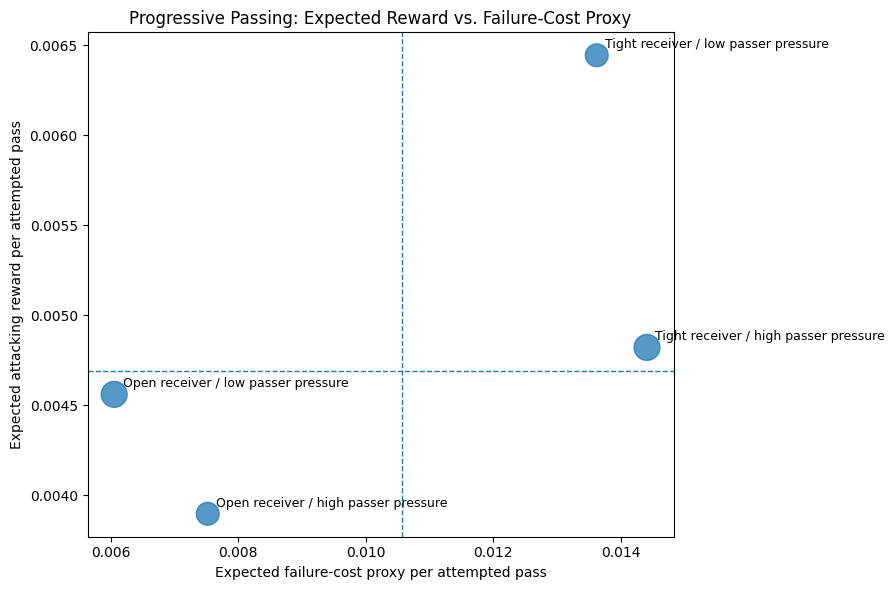

In [22]:
# ---------------------------------------------------------
# 7.4 Reward-risk matrix
# ---------------------------------------------------------

fig, ax = plt.subplots(figsize=(9, 6))

sizes = 80 + 0.35 * profile_summary["attempts"]

ax.scatter(
    profile_summary["expected_failure_cost_proxy"],
    profile_summary["expected_attacking_reward"],
    s=sizes,
    alpha=0.75,
)

for _, row in profile_summary.iterrows():
    ax.annotate(
        row["context_profile"],
        (
            row["expected_failure_cost_proxy"],
            row["expected_attacking_reward"],
        ),
        xytext=(6, 5),
        textcoords="offset points",
        fontsize=9,
    )

ax.axvline(
    failure_cost_cut,
    linestyle="--",
    linewidth=1,
)

ax.axhline(
    reward_cut,
    linestyle="--",
    linewidth=1,
)

ax.set_title(
    "Progressive Passing: Expected Reward vs. Failure-Cost Proxy"
)

ax.set_xlabel(
    "Expected failure-cost proxy per attempted pass"
)

ax.set_ylabel(
    "Expected attacking reward per attempted pass"
)

plt.tight_layout()
plt.show()


In [23]:
# ---------------------------------------------------------
# 7.5 Compact decision-output table
# ---------------------------------------------------------

decision_output = profile_summary[
    [
        "context_profile",
        "attempts",
        "completion_rate_pct",
        "mean_receiver_space",
        "mean_passer_pressure_distance",
        "mean_packing_count",
        "mean_lane_density",
        "expected_attacking_reward",
        "expected_lost_start_value",
        "expected_opponent_exposure",
        "expected_failure_cost_proxy",
        "net_value_proxy",
        "reward_risk_quadrant",
    ]
].copy()

display(decision_output.round(4))


,context_profile,attempts,completion_rate_pct,mean_receiver_space,mean_passer_pressure_distance,mean_packing_count,mean_lane_density,expected_attacking_reward,expected_lost_start_value,expected_opponent_exposure,expected_failure_cost_proxy,net_value_proxy,reward_risk_quadrant
0,Open receiver / low passer pressure,765,83.6601,11.6426,8.6221,3.6641,0.5869,0.0046,0.0027,0.0034,0.0061,-0.0015,Lower reward / lower failure cost
1,Open receiver / high passer pressure,542,80.6273,10.5247,2.7044,3.8487,1.5886,0.0039,0.0036,0.0039,0.0075,-0.0036,Lower reward / lower failure cost
2,Tight receiver / low passer pressure,542,63.4686,4.0029,7.0296,4.8635,1.1937,0.0064,0.0071,0.0065,0.0136,-0.0072,Higher reward / higher failure cost
3,Tight receiver / high passer pressure,765,63.2680,3.8607,2.5178,4.2549,1.8667,0.0048,0.0075,0.0069,0.0144,-0.0096,Higher reward / higher failure cost


# 8. Executive Findings & Limitations

**This section is intentionally left for interpretation after the empirical outputs have been reviewed.**

The final write-up should distinguish clearly between:

- descriptive findings from the available 34-match sample;
- destination-standardized contextual comparisons;
- decision proxies constructed from xT;
- and claims that the analysis cannot support.

The final limitations section will explicitly address 360 visibility, receiver-location approximation, proxy definitions, observational confounding, sample representativeness, and the fact that downstream calculations treat the estimated xT surface as fixed.


## Save Analytical Outputs

The following files are sufficient for the README and final portfolio reporting.
The event-level context table is retained for reproducibility, while the smaller
summary tables capture the main analytical results and the two quality checks
used before final interpretation.


In [24]:
# ---------------------------------------------------------
# Save outputs for README / final reporting
# ---------------------------------------------------------

progressive_360_df.to_csv(
    PROCESSED_DIR / "progressive_360_context.csv",
    index=False,
)

coverage_bias_check.to_csv(
    PROCESSED_DIR / "coverage_bias_check.csv",
    index=False,
)

context_completion_summary.to_csv(
    PROCESSED_DIR / "context_completion_summary.csv",
    index=False,
)

receiver_space_sensitivity_summary.to_csv(
    PROCESSED_DIR / "receiver_space_sensitivity_summary.csv",
    index=False,
)

same_destination_summary.to_csv(
    PROCESSED_DIR / "same_destination_context_summary.csv",
    index=False,
)

profile_summary.to_csv(
    PROCESSED_DIR / "decision_profile_summary.csv",
    index=False,
)

decision_output.to_csv(
    PROCESSED_DIR / "decision_output.csv",
    index=False,
)

print("Notebook 03 analytical outputs saved successfully.")


Notebook 03 analytical outputs saved successfully.


# 8. Executive Findings & Limitations

## Executive Findings

The analysis shows that progressive passing cannot be evaluated through attacking
reward alone. The defensive and tactical context in which an action is attempted
is strongly associated with its execution reliability.

### 1. Receiver space is a major execution constraint

Progressive-pass completion rises substantially as the receiver becomes more
open.

Across the full 360 sample, completion increases from approximately **58%** in
the tightest receiver-space quartile to **86%** in the most open quartile.

This relationship remains visible under a stricter receiver-location sensitivity
check. Restricting the analysis to passes for which the approximated receiver is
within 10 coordinate units of the recorded pass endpoint retains 1,447 attempts.
Within this subset, completion rises from approximately **71%** in the tightest
receiver-space group to **96%** in the most open group.

At the same time, successfully completed passes from tighter receiver situations
generate larger average changes in attacking state value.

This indicates a clear reward-execution trade-off: more difficult receiving
conditions are associated with lower reliability but potentially greater reward
when the action succeeds.

### 2. Defensive congestion matters beyond simple destination value

Packing and passing-lane density show similar patterns.

Completion decreases as more opponents are bypassed or occupy the passing lane,
while successful passes in these more demanding situations tend to generate
larger changes in attacking value.

The relationship is therefore not adequately described by completion or reward
alone.

### 3. Context differences remain after conditioning on destination

To reduce the influence of spatial destination, completion was compared within
the same 12 × 8 destination states.

After destination standardisation, passes toward receivers with greater space
retain an estimated completion advantage of approximately **23.6 percentage
points**.

Lower passer pressure retains a smaller but still meaningful completion
advantage of approximately **12.4 percentage points**.

The favorable receiver-space condition produces higher completion in 23 of 28
eligible destination states, while lower passer pressure produces higher
completion in 24 of 33 eligible states.

These comparisons strengthen the evidence that execution reliability is related
to tactical context rather than only to where the pass is directed.

### 4. Higher attacking reward can coincide with substantially greater downside

The final decision layer combines three components:

- attacking reward when the pass succeeds;
- probability of successful execution;
- a proxy for the cost of failure, including lost attacking state value and
  estimated opponent threat after possession is lost.

Among the four contextual profiles, **open receiver / low passer pressure**
provides the most favorable relative balance between attacking reward and
failure cost.

Attempts toward tightly covered receivers produce higher attacking reward when
successful, but their lower completion probability creates substantially larger
expected failure costs.

The combination **tight receiver / high passer pressure** produces the least
favorable relative reward-risk profile in the analysed sample.

The resulting decision framework therefore suggests that progressive actions
should not be evaluated through progression volume or successful-pass value
alone. Execution context materially changes the risk associated with attempting
the action.

## Decision Implications

For performance analysis, the results support separating progressive-pass KPIs
into three dimensions:

1. **attacking reward** generated when the action succeeds;
2. **execution reliability** under the observed tactical context;
3. **failure exposure** associated with losing possession.

This structure provides more decision-relevant information than a single
progressive-pass count or completion percentage.

In particular, receiver availability and defensive congestion can help
distinguish between progressive actions that offer attractive attacking
opportunities and actions whose potential reward is accompanied by substantial
execution risk.

## Limitations

The analysis is based on a 34-match sample and should not be interpreted as a
representative league-wide Bundesliga estimate.

StatsBomb 360 information is available for approximately **78%** of progressive
pass attempts. Completion is slightly higher among passes with 360 information
than among passes without it, although conditional attacking reward is similar.
The 360 subset should therefore not be assumed to be missing completely at
random.

Receiver position is approximated using the visible teammate closest to the
recorded pass endpoint. A sensitivity analysis with a maximum endpoint
approximation error of 10 coordinate units preserves the main receiver-space
pattern, but the measure remains a proxy rather than an observed receiver
identity.

The same-destination comparisons condition on spatial destination states but do
not control for every possible confounding factor. They should therefore be
interpreted as descriptive conditional comparisons rather than causal effects.

The failed-pass exposure measure is also a modelling proxy. It mirrors the
failed-pass endpoint into the opponent's attacking direction and maps that
location to the previously estimated xT surface. It does not reconstruct the
actual subsequent possession sequence.

The net-value measure should consequently be interpreted only as a comparative
decision proxy across contextual profiles. A negative value does not establish
that the underlying pass type is strategically undesirable.

Finally, the xT surface itself is estimated from the analysed match sample and
is treated as fixed in subsequent calculations. Uncertainty from estimation of
the xT surface is not propagated through all downstream statistics.